# Perceptron Experiment

## Aim

Implement a perceptron classifier from scratch and investigate its behaviour on a
two-class, linearly separable dataset.

In particular:
- implement the perceptron learning rule using NumPy;
- visualise the learned decision boundary;
- record the number of misclassifications during training;
- relate the observed convergence to the perceptron convergence theorem.

In [110]:
import numpy as np
import matplotlib.pyplot as plt

In [111]:
X = np.array([[1,2],
            [2,1],
            [5,3],
            [4,1],
            [5,7],
            [-6,-1],
            [-2,-2],
            [-1,-3],
            [-5,-4],
            [-1,-6]])
d = np.array([1,1,1,1,1,-1,-1,-1,-1,-1])
print(X.shape)
print(d.shape)

(10, 2)
(10,)


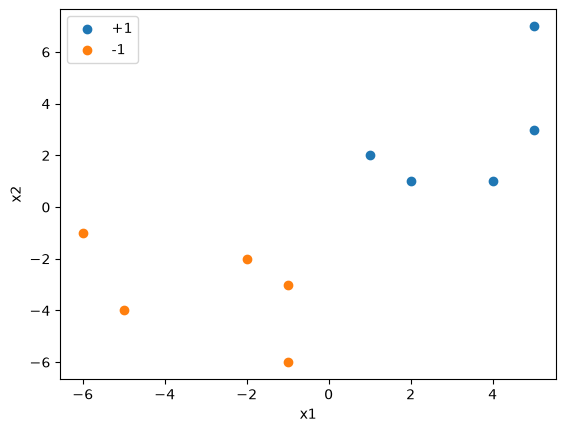

In [112]:
plt.scatter(X[d == 1, 0], X[d == 1, 1], label = '+1')
plt.scatter(X[d == -1, 0], X[d == -1, 1], label = '-1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [113]:
w = np.array([0.0,0.0])
b = 0.0

In [114]:
v = w @ X[0] + b
print(v)

0.0


In [115]:
y = -1 if v < 0 else 1
print(y)

1


In [116]:
n = 0.1

In [117]:
mistakes = 0
for i in range(len(d)):
    v = w @ X[i] + b
    y = -1 if v < 0 else 1
    w = w + n * (d[i] - y) * X[i]
    b = b + n * (d[i] - y)
    if y != d[i]:
        mistakes += 1

print("w =", w)
print("b =", b)
print("mistakes = ", mistakes)

w = [1.2 0.2]
b = -0.2
mistakes =  1


In [118]:
X = np.array([[1,2],
            [2,1],
            [5,3],
            [4,1],
            [5,7],
            [-6,-1],
            [-2,-2],
            [-1,-3],
            [-5,-4],
            [-1,-6]])
d = np.array([1,1,1,1,1,-1,-1,-1,-1,-1])
w = np.array([0.0,0.0])
b = 0.0
n = 0.1

In [119]:
mistakes = 1
epoch = 1
while mistakes != 0:
    mistakes = 0
    for i in range(len(d)):
        v = w @ X[i] + b
        y = -1 if v < 0 else 1
        w = w + n * (d[i] - y) * X[i]
        b = b + n * (d[i] - y)
        if y != d[i]:
            mistakes += 1
    print(f"\nEpoch: {epoch}")
    print("w =", w)
    print("b =", b)
    print("mistakes = ", mistakes)
    epoch += 1
    


Epoch: 1
w = [1.2 0.2]
b = -0.2
mistakes =  1

Epoch: 2
w = [1.2 0.2]
b = -0.2
mistakes =  0


In [120]:
x1 = np.linspace(-7, 7, 100)
x2 = - (w[0] * x1 + b) / w[1]

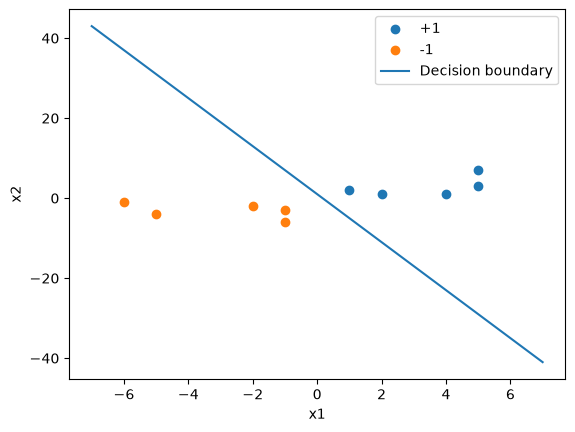

In [121]:
plt.scatter(X[d == 1, 0], X[d == 1, 1], label='+1')
plt.scatter(X[d == -1, 0], X[d == -1, 1], label='-1')

plt.plot(x1, x2, label='Decision boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [122]:
X = np.array([[1,2],
            [2,1],
            [5,3],
            [4,1],
            [5,7],
            [-6,-1],
            [-2,-2],
            [-1,-3],
            [-5,-4],
            [-1,-6]])
d = np.array([1,1,1,1,1,-1,-1,-1,-1,-1])
w = np.array([0.0,0.0])
b = 0.0
n = 0.1

mistakes = 1
epoch = 0
while mistakes != 0 and epoch < 100:
    mistakes = 0
    for i in range(len(d)):
        v = w @ X[i] + b
        y = -1 if v < 0 else 1
        w = w + n * (d[i] - y) * X[i]
        b = b + n * (d[i] - y)
        if y != d[i]:
            mistakes += 1
    epoch += 1
print(f"\nEpoch: {epoch}")
print("w =", w)
print("b =", b)
print("mistakes = ", mistakes)


Epoch: 2
w = [1.2 0.2]
b = -0.2
mistakes =  0


In [123]:
X = np.array([[0,1],
              [1,0],
              [0,0],
              [1,1]])
d = np.array([1,1,-1,-1])
w = np.array([0.0,0.0])
b = 0.0
n = 0.1

mistakes = 1
epoch = 0
while mistakes != 0 and epoch < 100:
    mistakes = 0
    for i in range(len(d)):
        v = w @ X[i] + b
        y = -1 if v < 0 else 1
        w = w + n * (d[i] - y) * X[i]
        b = b + n * (d[i] - y)
        if y != d[i]:
            mistakes += 1
    epoch += 1
if mistakes == 0:
    print("Converged")
else:
    print("Did not converge")
print("w =", w)
print("b =", b)

Did not converge
w = [-0.2  0. ]
b = -0.4


## Results and interpretation

I started with an obviously linearly separable dataset and worked from the most basic principles to construct a perceptron. This found weights and bias that represented a hyperplane that separated all the points of each class. I slowly built up my work until I had the full block of code including a while loop for multiple epochs and a for loop to go through all the training data every epoch. I then tested this algorithm against different datasets that were both linearly and non linearly separable modifying as I went until I had an implementation capable of testing both linearly separable and non-linearly-separable datasets.

This is my first implementation of a neural-network model: a single perceptron, but will bridge important connections to more advanced models later on.

My sepearable dataset converged to a zero mistake epoch after 2 loops attaining a weight vector of (1.2, 0.2) and bias -0.2, which represents a hyperplane x2 = -6 x1 + 1. This differs from my initial observation of x2 = -x1, showing that it doesnt guarantee a unique or optimal solution simple one that works.

My inseparable dataset never converged after 100 loops. It is important to note the achieved weight and bias are useless and do not represent a minimal error solution nor an optimal solution. As well as this a single perceptron can only represent a linear decision boundary and so no amount of epochs could have solved this problem.